In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('max_colwidth', None)
import torch
import transformers
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix,
classification_report,
accuracy_score)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/movie_reviews.csv")
df.head(5)

,review
0,"Okay, I know this does'nt project India in a good light. But the overall theme of the movie is not India, it's Shakti. The power of a warlord, and the power of a mother. The relationship between Nandini and her husband and son swallow you up in their warmth. Then things go terribly wrong. The interaction between Nandini and her father in law - the power of their dysfunctional relationship - and the lives changed by it are the strengths of this movie. Shah Rukh Khan's performance seems to be a mere cameo compared to the believable desperation of Karisma Kapoor. It is easy to get caught up in the love, violence and redemption of lives in this film, and find yourself heaving a sigh of relief and sadness at the climax. The musical interludes are strengths, believable and well done."
1,"Despite John Travolta's statements in interviews that this was his favorite role of his career, ""Be Cool"" proves to be a disappointing sequel to 1995's witty and clever ""Get Shorty.""<br /><br />Travolta delivers a pleasant enough performance in this mildly entertaining film, but ultimately the movie falls flat due to an underdeveloped plot, unlikeable characters, and a surprising lack of chemistry between leads Travolta and Uma Thurman. Although there are some laughs, this unfunny dialog example (which appeared frequently in the trailers) kind of says it all: Thurman: Do you dance? Travolta: Hey, I'm from Brooklyn.<br /><br />The film suggests that everyone in the entertainment business is a gangster or aspires to be one, likening it to organized crime. In ""Get Shorty,"" the premise of a gangster ""going legitimate"" by getting into movies was a clever fish-out-of water idea, but in ""Be Cool,"" it seems the biz has entirely gone crooked since then.<br /><br />The film is interestingly casted and the absolute highlight is a ""monolgue"" delivered by The Rock, whose character is an aspiring actor as well as a goon, where he reenacts a scene between Gabrielle Union and Kirsten Dunst from ""Bring It On."" Vince Vaughan's character thinks he's black and he's often seen dressed as a pimp-- this was quite funny in the first scene that introduces him and gets tired and embarrassing almost immediately afterward.<br /><br />Overall, ""Be Cool"" may be worth a rental for John Travolta die-hards (of which I am one), but you may want to keep your finger close to the fast forward button to get through it without feeling that you wasted too much time. Fans of ""Get Shorty"" may actually wish to avoid this, as the sequel is devoid of most things that made that one a winner. I rate this movie an admittedly harsh 4/10."
2,"I am a kung fu fan, but not a Woo fan. I have no interest in gangster movies filled with over-the-top gun-play. Now, martial arts; *that's* beautiful! And John Woo surprised me here by producing a highly entertaining kung fu movie, which almost has *too much* fighting, if such a thing is possible! This is good stuff.<br /><br />Many of the fight scenes are very good (and some of them are less good), and the main characters are amusing and likable. The bad guys are a bit too unbelievably evil, but entertaining none the less. You gotta see the Sleeping Wizard!! He can only fight when he's asleep - it's hysterical!<br /><br />Upon repeated viewings, however, Last Hurrah For Chivalry can tend to get a little boring and long-winded, also especially because many of the fight scenes are actually not that good. Hence, I rate it ""only"" a 7 out of 10. But it really is almost an ""8"".<br /><br />All in all one of the better kung fu movies, made smack-dab in the heart of kung fu cinema's prime. All the really good kung fu movies are from the mid- to late 1970ies, with some notable exceptions from the late '60ies and early '70ies (and early '80ies, to be fair)."
3,"He seems to be a control freak. I have heard him comment on ""losing control of the show"" and tell another guest who brought live animals that he had one rule-""no snakes."" He n

In [ ]:
df.shape

(10000, 1)

In [ ]:
df.isna().sum()

,0
review,0


In [ ]:
df.duplicated().sum()

np.int64(18)

In [ ]:
reviews = df.copy()

In [ ]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# there are many other models to choose from too!
# https://www.sbert.net/docs/pretrained_models.html
# https://huggingface.co/spaces/mteb/leaderboard
# model = SentenceTransformer('BAAI/bge-base-en-v1.5')

In [ ]:
# Train
model.encode(['hello my name is Noha!'])

array([[-3.49791795e-02,  1.66694615e-02, -1.31983534e-02,
         3.58874276e-02, -1.04087420e-01, -4.76595238e-02,
         9.52017903e-02, -8.00467357e-02, -4.45623463e-03,
        -6.80419710e-03,  3.33455838e-02, -9.88072753e-02,
         4.75668609e-02,  3.71972099e-04,  8.20786599e-03,
         1.82461657e-03,  6.88851029e-02,  1.98261794e-02,
        -4.52868566e-02,  6.51774509e-03, -1.08542759e-02,
         5.60594276e-02, -8.64362493e-02, -1.55830318e-02,
        -1.06262408e-01, -3.91618423e-02, -2.46821046e-02,
         2.20104884e-02, -4.31577004e-02, -1.14715226e-01,
         1.58639420e-02,  6.32228032e-02,  4.79906574e-02,
         7.02976808e-02,  3.72407623e-02,  8.34294595e-03,
        -1.11364461e-01, -3.30074243e-02, -3.18114981e-02,
         2.80918423e-02, -3.06570604e-02, -7.06724524e-02,
        -4.03477959e-02, -5.05606532e-02,  2.29127482e-02,
         2.34233756e-02,  2.47722249e-02,  2.52774619e-02,
         4.44516614e-02,  2.54400577e-02, -1.12875164e-0

In [ ]:
model.encode(['Hi my name is Noha?'])

array([[-4.65998724e-02,  2.30279770e-02, -3.07521615e-02,
         2.35177223e-02, -9.60683897e-02, -3.85911837e-02,
         1.56904340e-01, -7.23862574e-02,  2.94148270e-02,
        -2.31782924e-02,  4.50588316e-02, -1.24133900e-01,
         4.30774353e-02, -1.88576262e-02,  3.71377282e-02,
         2.31237821e-02,  5.54417893e-02, -8.57521128e-03,
        -8.70521069e-02, -4.66246642e-02, -2.21951324e-02,
         7.15516061e-02, -8.06819499e-02, -1.98374577e-02,
        -1.01172864e-01, -4.03318293e-02, -9.17282654e-04,
         2.38698348e-02, -3.33805643e-02, -8.75661150e-02,
         7.25537306e-04,  5.49044088e-02,  5.66962883e-02,
         6.02638647e-02,  3.23578343e-02,  1.64539972e-03,
        -8.28109682e-02, -3.36230956e-02, -2.62831505e-02,
         3.92505266e-02, -2.62128301e-02, -7.65017271e-02,
        -2.40729637e-02, -4.24216688e-02,  2.82586329e-02,
        -2.71928450e-03,  7.28312973e-03, -1.13268038e-02,
         3.71338688e-02,  2.74867509e-02, -1.33228570e-0

In [ ]:
# define function to calculate the cosine score between tow embeddings
def cosine_score(text):
  embedding = model.encode(text)
  norm1 = np.linalg.norm(embedding[0])
  norm2 = np.linalg.norm(embedding[1])
  cosine_similar_score = np.dot(embedding[0], embedding[1])/(norm1 * norm2)
  return cosine_similar_score

In [ ]:
sentence_1 = 'The dog is walking on the beach'
sentence_2 = 'On the beach is a walking dog'
cosine_score([sentence_1, sentence_2])

np.float32(0.89286894)

**The  high cosine show that the sentences score are semantically similar**

In [ ]:
sentence_1 = 'The movie is good'
sentence_2 = 'The movie is bad'
cosine_score([sentence_1, sentence_2])

np.float32(0.74507594)

In [ ]:
sentence_1 = 'The skay is blue'
sentence_2 = 'The sun is shine'
cosine_score([sentence_1, sentence_2])

np.float32(0.23955333)

**The low cosine show that the sentences is not similar**

## Encoding dataset.
## Setting the device to Gpu

In [ ]:
# Setting the device to Gpu if available else cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Encoding dtdset
embedding_matrix = model.encode(reviews['review'], device=device, show_progress_bar=True)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [ ]:
# print the shape of embedding matrix
embedding_matrix.shape

(10000, 384)

In [ ]:
# Print the embeding matrix of first review dataset
embedding_matrix[0]

array([-7.45214298e-02,  2.59453780e-03, -3.34989130e-02, -4.84162569e-02,
       -3.84775475e-02,  6.37952834e-02,  5.54266805e-03,  4.06936258e-02,
        6.29823357e-02, -3.84879410e-02, -1.27104996e-02, -2.12660413e-02,
        6.79038465e-02,  2.27340637e-03,  1.14876637e-03,  2.30603851e-02,
        8.18004981e-02,  4.14928421e-02, -2.12946627e-02, -2.29654647e-02,
        2.09020693e-02, -2.93925442e-02,  9.37751457e-02, -2.93005370e-02,
       -6.34454489e-02, -1.70642026e-02,  1.12413354e-01, -2.24412195e-02,
       -6.00714236e-02,  1.55951614e-02,  2.08699703e-02,  7.55285844e-02,
       -6.04214668e-02,  2.33692932e-03, -1.79052521e-02,  7.56649375e-02,
        9.78590176e-03,  2.67772675e-02, -1.30181983e-02, -1.76513679e-02,
        3.84344533e-02,  3.93548384e-02,  5.56520410e-02, -1.35076111e-02,
        5.03627993e-02, -7.22084939e-02, -2.37328522e-02, -1.08479701e-01,
        2.67260633e-02, -5.05364574e-02, -8.09637681e-02,  5.58139868e-02,
       -1.44373765e-03, -

## Query from dataset

In [ ]:
# define the function to compute the top k similar sentences for given query
def get_top_k_similar_sentences(embedding_matrix, query, k):
  query_embedding = model.encode(query_text)
  score_vector = np.dot(embedding_matrix, query_embedding.T)
  top_k_indices = np.argsort(score_vector)[::-1][k:]
  return reviews.loc[list(top_k_indices), 'review']

## How to define Query text

In [ ]:
query_text = 'Funny movies'
# Display the top 5 similar sentences
get_top_k_similar_sentences(embedding_matrix, query_text, 5)

,review
2645,"Ok, so there's always people out there that seem to make it a point not to like movies because they're good, but instead choose to like movies based on how depressing or boring they can be, or whether they're from a foreign country. All that aside, One Crazy Summer is the perfect example of what a great American teen comedy should be. The jokes are a good mix of slapstick (a la Bobcat Goldthwait), surreal (Bobcat under the inspired direction of Steve Holland), and dry (John Cusack, one of the most morosely dry and funny actors in American cinema), and there is no character in this movie who does not deliver at least one funny line (ok, except Demi Moore).<br /><br />Yes, it's immature, yes, it's screw-ball, yes, Bobcat dresses up like Godzilla and trashes a scale-model of a seafood restaurant. It's also funny as hell. Watch it."
7385,"If I ever write movies or make them, i would want one of them to be like this one. I enjoy the goof-ball sense of humor and jokes contained within. This movie does stupid things without looking like it. The names of the places and characters are priceless, Generic New York High School, Squid Calimari (George's sister), etc...genius. I've seen this movie so many times because it was a cable tv staple while I was growing up, of course I didn't get all of the jokes back than but it was still funny.This movie is a time-less classic."
6573,"Unfortunately this is not as good as any of the other films that Jim Carrey (producing and starring) and Brian Grazer have worked on together, but bits of it are definitely worth a look for laughs. Basically Dick Harper (Carrey) thinks he is being promoted to a better job. That's until the company of Dynocorpe sinks and closes down. Now Dick and his wife Jane (Téa Leoni), and their son of course, are in trouble with money. No matter what they try, they can't raise the kind of money they really want. So they start robbing a few places. And then they decide to rob the guy that set Dick up, his ex-boss Jack McAllister (Alec Baldwin). I think the most laughable bits are when Carrey's in the elevator singing ""I Believe I Can Fly"" and the bit when he ties up someone in a robbery, and is speaking with a voice changer (he sounds like a crap robot). Okay!"
852,"one of the worst films I have EVER seen, but extremely funny (not on purpose though). Every scene that contains anything to do with; aircraft, romance, script or acting is badly messed up.<br /><br />I recommend this film for all pilots, it´s so bad that you should burst into laughter at some point in the film (also see Airport 79:the Concorde, for the same reason).<br /><br />Anyone else, avoid this film like the plague (except for fans of B-movies, of course)<br /><br />enjoy"
4329,"<br /><br />This movie is só incredibly unfunny it makes any man want to cry, the cliché are put on thicker than 5-year old peanut butter and in such a way that it actually sucks humour out of your heart, every single joke was badly timed and wouldn't have been funny if it were timed correctly.<br /><br />Don't see this movie, there's a real chance you'll never be able to enjoy going to comedies again...ever."
...,...
6710,"I loved Adrianne Curry before this show. I thought she was great on Top Model and was really glad when she won. I also liked Chris Knight, he seems like a great guy. But this show just made me SICK! I'm so angry at both of them for what happened on that show. I don't care that they were different ages, I know age can't stand between love. But Adrianne, you had been together for ONLY SEVEN MONTHS. It didn't surprise me at all that he hadn't proposed. And I don't see the appeal of forcing someone to marry you before they're ready. If it's meant to be, then why not just ENJOY each other's company and love each other, and let it come naturally? Turning a wedding ring into a ball and chain was completely unnecessary, it's stupidly obvious that Chris loves you, with or without a ring. And Chris, shame on yo

In [ ]:
query_text = 'Romantic movies'
# Display the top 5 similar sentences
get_top_k_similar_sentences(embedding_matrix, query_text, 5)

,review
9549,the most amazing combination of love and psyche of two young people.presented in the most sublime manner and definitely touches your heart.a rare combination where the sequel surpasses the prequel in both storytelling and intensity of emotions.the movie re affirms your faith in love and pain of separation. the joy of seeing your most beloved is unparalleled and anything can be sacrificed. Ethan and Julie have essayed eternal characters with such simplicity that gives the movie a sheer joy and love to watch. A must see movie for all the people who believe in true love. by far the most romantic(at least one of them) movie of all times.
4892,"Excellent and moving story of the end of a uniquely intimate affair. Then again, the point of the film, to paraphrase another comment, is that every relationship can be unique and intimate. A truly quality short film which caught me at my busiest, yet had the power to pull me down onto the sofa and watch, fixed and quiet, for the duration. Bobby and Tessa are powerfully moving characters and anyone who has suffered the end of a love affair will find this film to be a cathartic exercise. Beyond that, the 'film within a film' idea plays out very well with this cast and is quite riveting, though in a somewhat melancholic way."
8312,"Screwball comedy about romantic mismatches in New York City. Peter Bogdanovich is obviously in love with all the women in his picture--he reveres them--yet Audrey Hepburn is (naturally) put a notch above the others because, after all, she's the princess Bogdanovich probably fell in love with at the movies 30 years prior. He shoots her in loving close-ups, gets right in the sheets between her and a wonderfully hard-boiled/soft-boiled Ben Gazzara, and allows her room to sparkle throughout. The love-connections made in the course of the film are fast and amusing, though I did tire of John Ritter's TV-styled klutziness. Colleen Camp, Dorothy Stratten, and the grounded, earthy-sensual Patti Hansen are all exciting to watch. But it's really Hepburn's valentine and she absolutely glows. *** from ****"
5569,"It's Valentines Day and we decided to stay in, have a nice dinner, and watch this movie on TCM instead of going out. We're in our 40's - 50's, love romance, and are both ""softies"" but this movie just bombed for us (it's hard to imagine that it was nominated for Oscars, etc. but I guess that was then). The cinematography was beautiful but for the most part the movie as a whole is terribly dated. Jennifer Jones' character made so many references to her being Eurasion that we started counting and after a while we were giggling every time she said it. Add to that the ""theme song"" played incessantly throughout the film and we couldn't wait for it to be over so we could watch the evening news."
4694,"One of those, ""Why was this made?"" movies. The romance is very hard to swallow. It is one of those romances, that, suddenly, ""click"" - they are in love. The movie is filled with long pauses and uncomfortable moments - the drive-in restaurant being the most notable. Charles Grodin does a credible job but for most of the movie it's just him and Louise Lasser. Ask yourself, do you want to watch Grodin with his neurosis and Lasser with her neurosis together for a hour and half?"
...,...
8923,"Let me first off say that I am a believer of ghosts, and I do indeed know they exist. I have had enough experiences with them to know they are there.<br /><br />What I hate is the people who bring the Bible and Religion into all of this. People forget there is more than one ""Bible"", thousands of religions and beliefs, and different ways to interpret what is said in the Bible. Not everyone believes in God, and not everyone believes in stereo-typical religion. <br /><br />Religion does not make everything fact, one of the things I should mention in the Bible that many do not know is that even the most rampant Bible thumper is breaking the very rules written within....you are

In [ ]:
query_text = 'Science fiction'
# display top 5 similar sentences
get_top_k_similar_sentences(embedding_matrix, query_text, 5)

,review
4135,"Being a science fiction fan from my early childhood (long time since) I always hated implausible plots. It's a pity that most authors of science fiction stories for children do not show this kind of respect for their audience. I always suspected them of thinking: ""children are to dumb to realise, so we don't have to strive"". The writer of ""Science Fiction (2002)"" is no exception. The story is about a boy who is instigated by his new friends to spy after his parents, because they think that the parents are aliens. As intriguing the idea sounded to me, as much was I bored by its realisation. It seemed to me that the filmmakers had exactly this one idea and tried to stretch it over the ninety minutes by dunking it into a dark, stylish and painstakingly slow atmosphere. The only thing that kept me in my seat was the question ""how do they manage to get out of this implausible rubbish""? And then - bang - they did not even try. So if you are looking for good entertainment for both children and parents, go and watch ""Klatretøsen (2002)"" instead."
1329,"There is one adjective that describes everything about this film - acting, plot, effects, continuity, etc. - and that word is poor. The government wants to asses the effects of space travel on certain organisms but the capsule crashes and a mutant something-or-other (looks like a guy in an ape suit with the top of a football helmet over his face) wreaks havoc around the accident scene, which includes a favorite place for the window-fogging, partying set. Therefore, some young people - as well as a law enforcement officer - are among the creature's victims. You gotta be extremely unparticular about how you spend your time - or rich, if you spend any money - to view this epic."
8790,"The script seems to have been wholesale (ahem ahem, cough cough) ""borrowed"" from a certain other movie involving using a self-propelled manned drilling machine. Scene by scene, the two movies were almost identical. Just enough of the serial numbers filed off in this one to prevent a copyright infringement lawsuit.<br /><br />But other than that, I have to say I found this somewhat entertaining as I enjoy deep-underground-in-the-earth genre of movies. It's a little bit on the stupid side as far as the science goes, but if one is willing to squint one's eyes real hard and pretend one didn't notice that scientific gaffe here and there and all over, this movie is almost bearable. Far better than ""Supernova"" which was another flick that Luke Perry had a leading role in that was so dumb, dumb, dumb that nothing could save it. A note to movie makers: employ someone who knows something about the subject the movie deals with. It would be a very small part of the movie budget, but it would have a big effect overall in helping prevent your audience from guffawing at you for doing dumb science.<br /><br />Production values: almost passable. I've seen far worse in my time.<br /><br />A new thought for disaster movies: instead of them always having a happy ending where the world gets saved yet once again, how about some where things are a tad bit more realistic, where sometimes even the very best efforts still end up in failure. Particularly when the problem that needs to be resolved was caused in the first place by sheer stupidity. Stupidity-caused disaster movies with glowing, heartwarming endings sort of backhandedly justify stupidity by stating, ""No matter how awful a problem is caused by braindead stupidity, it can be fixed."" Which is definitely not the case. A self-caused disaster movie with an unhappy ending would serve better as cautionary tale of ""Don't be so damn stupid in the first place."" Should you watch this movie? If you're bored and you've seen everything else in the scifi section at your local video rental store, sure, why not. But do avoid ""Supernova"" as I can assure you that you're not THAT bored. That definitely was not one of Luke Perry's better movies. This one is bette

## Categorization the movies reviews

In [ ]:
query_for_categorization = ["A funny movie with a dramitic story",
                            "A funny movie with great performance for the actor",
                            "A romantic movie with sad story",
                            "A romantic movie  with  a happy endding",
                            "A romantic movie with unconvincing performance",
                            "A romantic movie with week senario",
                            "Creative science fiction movie",
                            "Scary sciencefiction movie",
                            "A complex science fiction movie"]

In [ ]:
# Create dictionary
categorization_reviews = {}
# get number of similitry
k = 500
# loop over query
for query in query_for_categorization:
  categorization_reviews[query] = get_top_k_similar_sentences(embedding_matrix, query, k)

In [ ]:
i = 0
print("Query Text", query_for_categorization[1], end='\n')
print("Similar reviews:", end='\n')
categorization_reviews[query_for_categorization[1]].head(10)

Query Text A funny movie with great performance for the actor
Similar reviews:


8340                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
i = 1
print("Query Text", query_for_categorization[1], end='\n')
print("Similar reviews:", end='\n')
categorization_reviews[query_for_categorization[1]].head(10)

Query Text A funny movie with great performance for the actor
Similar reviews:


8340                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
i = 2
print("Query Text", query_for_categorization[1], end='\n')
print("Similar reviews:", end='\n')
categorization_reviews[query_for_categorization[1]].head(10)

Query Text A funny movie with great performance for the actor
Similar reviews:


8340                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
i =2
print("Query Text", query_for_categorization[i], end='\n')
print("Similar reviews:", end='\n')
categorization_reviews[query_for_categorization[i]].head(10)

Query Text A romantic movie with sad story
Similar reviews:


8340                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
i = 3
print("Query Text", query_for_categorization[i], end='\n')
print("Similar reviews:", end='\n')
categorization_reviews[query_for_categorization[i]].head(10)

Query Text A romantic movie  with  a happy endding
Similar reviews:


8340                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
i = 4
print("Query Text", query_for_categorization[i], end='\n')
print("Similar reviews:", end='\n')
categorization_reviews[query_for_categorization[i]].head(10)

Query Text A romantic movie with unconvincing performance
Similar reviews:


8340                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
i = -1
print("Query Text", query_for_categorization[i], end='\n')
print("Similar reviews:", end='\n')
categorization_reviews[query_for_categorization[i]].head(10)

Query Text A complex science fiction movie
Similar reviews:


8340                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

**After categorical the reviews the model not category better it reapts some categories**

In [ ]:
from textblob import TextBlob


In [ ]:
# The TypeError was caused by trying to use a list as a dictionary key.
# To create a DataFrame with your query texts and similar reviews, you can structure the dictionary like this:
data = {'Query Text': query_for_categorization,
        'Similar Reviews': [categorization_reviews[query] for query in query_for_categorization]}

df_categorized_reviews = pd.DataFrame(data)
display(df_categorized_reviews)

Query Text  \
0                 A funny movie with a dramitic story   
1  A funny movie with great performance for the actor   
2                     A romantic movie with sad story   
3             A romantic movie  with  a happy endding   
4      A romantic movie with unconvincing performance   
5                  A romantic movie with week senario   
6                      Creative science fiction movie   
7                          Scary sciencefiction movie   
8                     A complex science fiction movie   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [ ]:
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Netural'
    else:
        return 'Negative'

In [ ]:
# Apply function to each review within each list of similar reviews
sentiments = []
for review_series in data['Similar Reviews']:
    sentiment_list = [get_sentiment(review) for review in review_series]
    sentiments.append(sentiment_list)

# Add the sentiments as a new column to the DataFrame.
# Since each entry in 'Similar Reviews' is a Series of reviews,
# the corresponding 'Sentiment' entry will be a list of sentiments for those reviews.
df_categorized_reviews['Sentiment'] = sentiments

display(df_categorized_reviews)

Query Text  \
0                 A funny movie with a dramitic story   
1  A funny movie with great performance for the actor   
2                     A romantic movie with sad story   
3             A romantic movie  with  a happy endding   
4      A romantic movie with unconvincing performance   
5                  A romantic movie with week senario   
6                      Creative science fiction movie   
7                          Scary sciencefiction movie   
8                     A complex science fiction movie   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [ ]:
# Convert Postiveand Negative to 1 and 0
df_categorized_reviews['Sentiment'] = df_categorized_reviews['Sentiment'].apply(lambda x: [1 if sentiment == 'Positive' else 0 for sentiment in x])
df_categorized_reviews

Query Text  \
0                 A funny movie with a dramitic story   
1  A funny movie with great performance for the actor   
2                     A romantic movie with sad story   
3             A romantic movie  with  a happy endding   
4      A romantic movie with unconvincing performance   
5                  A romantic movie with week senario   
6                      Creative science fiction movie   
7                          Scary sciencefiction movie   
8                     A complex science fiction movie   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [ ]:
# Generate sentiment labels for the entire dataset using the previously defined get_sentiment function
reviews['sentiment_label'] = reviews['review'].apply(get_sentiment)

# Convert Positive to 1, Neutral and Negative to 0
reviews['sentiment_label'] = reviews['sentiment_label'].apply(lambda x: 1 if x == 'Positive' else 0)

# Define independent variable (embedding matrix) and dependent variable (sentiment labels)
X = embedding_matrix
y = reviews['sentiment_label']

# Split data into train and test ratio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 384)
Shape of X_test: (2000, 384)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [ ]:
# Building modelRandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             recall_score,
                             precision_score,
                             f1_score)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [ ]:
# Get matrics score
accuracy_score(y_test, y_pred_rf)
recall_score(y_test, y_pred_rf)
precision_score(y_test, y_pred_rf)
f1_score(y_test, y_pred_rf)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.81      0.12      0.20       468
           1       0.79      0.99      0.88      1532

    accuracy                           0.79      2000
   macro avg       0.80      0.55      0.54      2000
weighted avg       0.79      0.79      0.72      2000



**When analysis sentiments positve is high recall score ~99%**

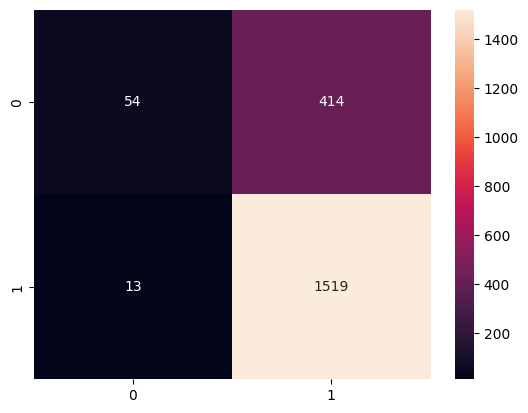

In [ ]:
# Plot confusion_metrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()